# Project 3 - Sales Analysis - Machine Learning

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Create machine learning model to predict new hypothesis data
- Show plots to attempt to answer new hypothesis


## Inputs

CSV files used:

Sales_InvoiceData_Visualization.csv


## Outputs

Pipeline for use in streamlit 
Plots to show the data and attempt to answer the hypothesis


## Additional Comments

- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [105]:
%matplotlib inline

#iimport libraries
import os
import pandas as pd
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#for ML experiments
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

#for creating the pipeline file needed by streamlit/Heroku
import joblib

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT


# Hypothesis Being Tested

- What are the predicted sales per month for next year?
- What are the predicted sales per territory for next year?

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [106]:
#model and image paths

#for test against existing values
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS8_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis8_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS8_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis8_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS8_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis8_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS8_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis8_test_forecast.png"

CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis9_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis9_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis9_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis9_test_forecast.png"

#for new predictions
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS8_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis8_predictions_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS8_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis8_predictions_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS8_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis8_predictions_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS8_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis8_predictions_forecast.png"


CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis9_predictions_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis9_predictions_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis9_predictions_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis9_predictions_forecast.png"


#DataFrame vars for visualisation
dfSalesDataML = None
dfSalesDataML_Work = None
dfTempML = None

#ML vars
dfTrain = pd.DataFrame()
dfTest = pd.DataFrame()
dfXTrain = pd.DataFrame()
dfyTrain = pd.DataFrame()
dfXTest = pd.DataFrame()
dfyTest = pd.DataFrame()
dfPlot = pd.DataFrame()
dfPredictedSales = pd.DataFrame()
dfSalesDataML_Temp1 = None
dfSalesDataML_Temp2 = None
dfSalesDataML_GroupedByTerritory = None
dfSalesDataML_GroupedByCustomer = None
dfSalesDataML_2017Predicted = None
dfSalesDataML_2018Predicted = None
df2018Monthly = None
df2018MonthlyPredicted = None
df2018Territory = None

lstNumericFeatures = list()
lstCategoricalFeatures = list()
lstFeatures = list()
lstStores = list()
lstSales = list()
lstMarkdown = list()

strTarget = ""

objModel = None
objPipeline = None
objMissingPreviousSales = None
objNumericTransformer = None
objCategoricalTransformer = None
objPreProcessor = None
objyPred = None
objyPred = None
objMissingColumns = None

fltMAE = 0.0
fltRMSE = 0.0
fltR2 = 0.0
fltActualTotal = 0.0
fltPredictedTotal = 0.0
fltDifference = 0.0
fltDifferencePercent = 0.0
flt2018Total = 0.0

intTestYear = 0
intPreviousYear = 0

#other vars
intYear = 0
fig = None
ax = None
intNum = 0
dictDataFrames = dict()
objPipeline = None
objModel = None
X = None
X_Const = None
y = None


## Set Current Directory To Base Project Directory

In [107]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_DataSet_Work

In [108]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
#open into DataFrame which can be re-used during visualisations for filtering etc
dfSalesDataML = dictDataFrames["Sales_InvoiceData_Visualisation.csv"]

#load special csv file for machine learning
dfSalesDataML_GroupedByTerritory = dictDataFrames["Sales_InvoiceData_GroupedByTerritory_Visualisation.csv"]

#load second special csv file for machine learning 
dfSalesDataML_GroupedByCustomer = dictDataFrames["Sales_InvoiceData_GroupedByCustomer_Visualisation.csv"]

3 csv Files Read Into DataFrames

DataFrames Created:
Sales_InvoiceData_GroupedByTerritory_Visualisation.csv
Sales_InvoiceData_GroupedByCustomer_Visualisation.csv
Sales_InvoiceData_Visualisation.csv




/Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis/assets/python_files/modETL_Library.py:452: DtypeWarning: Columns (0: InvoiceID) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTemp = pd.read_csv(os.getcwd() + modGlobal.CNST_STR_DATA_VISUALISATIONPATH + "/" + strFile)


## Transform Date Column To Datetime Format

In [109]:
#transform Date to datetime
dfSalesDataML["InvoiceDate"] = pd.to_datetime(dfSalesDataML["InvoiceDate"], format="%d/%m/%Y")

#check schema
dfSalesDataML.dtypes

#create a working copy of the base DataFrame
dfSalesDataML_Work = dfSalesDataML.copy()


# Initailise Work DataFrame

In [110]:
#setup work DataFrame
dfSalesDataML_Work = dfSalesDataML.copy() 


## Check Special csv For Any Data Anomalies That Might Skew Regression

Seems a bit stange foing this here, but actually a little EDA beforehand i.e. double checking is never a bad idea

In [111]:
#show DataFrame
dfSalesDataML_GroupedByTerritory.head(1000)


,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
0,0,Central/E.Anglia,20113,2011,55064.96
1,20,EU INV,20113,2011,6879.71
2,71,Non EU,20113,2011,220568.38
3,61,London,20113,2011,7376.94
4,50,House Account,20113,2011,1113.27
...,...,...,...,...,...
995,1261,Midlands and West,20167,2016,26122.96
996,1173,Central/E.Anglia,20167,2016,5346.21
997,1249,Midlands and East,20167,2016,19042.24
998,1185,EU,20167,2016,21742.57


## Observations: Aggregate The Data By TerritoryCodes With Monthly Invoice Totals

Some data anomalies appear:

Territory: 
- record 135 - territory of "none" (??) this is actually a real value, why is it in the data?
- Record 88 & 89 - West Midlands (record 592), also West Midlands (East) and West Midlands (West) 
  Why does West Midlands exist on its own?
  Also why no East Midlands East/West?(!)


# Hypothesis 8

What are the predicted sales per month for next year?


# Hypothesis 8 - Linear Regression Model - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [112]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and training data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()


# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

#configure train
dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "Month",
]

#configure categorial features
lstCategoricalFeatures = [
    "TerritoryCodes"
]

#configure pipeline
objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train
print("Training Linear Regression...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

#create DataFrame based on prediction values
dfSalesDataML_2017Predicted = dfTest.copy()
dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)

#totals
fltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100

#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")

#confgure DataFrame for plotting
dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby("YearMonth")[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save pipelie to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS8_TEST_PATH
)

#tell user saved
print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS8_TEST_PATH)


Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Linear Regression...
Training complete.

Inspect 2017 Forecast

Actual 2017:    £6,926,442.53
Predicted 2017: £6,822,519.16
Difference:     £103,923.37
Difference %:   1.50%
Linear Regression Results
Mean Absolute Error (MAE):  18,609.06
Root Mean Squared Error (RMSE): 29,873.94
R-Squared (R²):   0.6504

                            OLS Regression Results                            
Dep. Variable:             InvoiceAmt   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     213.6
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:28:18   Log-Likelihood:                -19424.
No. Observations:                1669   AIC:                        

# Observations: Hypothesis 8 - Linear Regression Model - Test

Wow! The R-squared is 0.6504, which is close enough to 1 to say this model works!

The OLS Regression has an R-squared of 0.821 for InvoiceAmt is also near 1, this proves that Hypothesis Zero is
not met with this regression model, next will put in a plot


# Hypothesis 8 - Linear Regression Plot - Test Plot

Visualise the model results

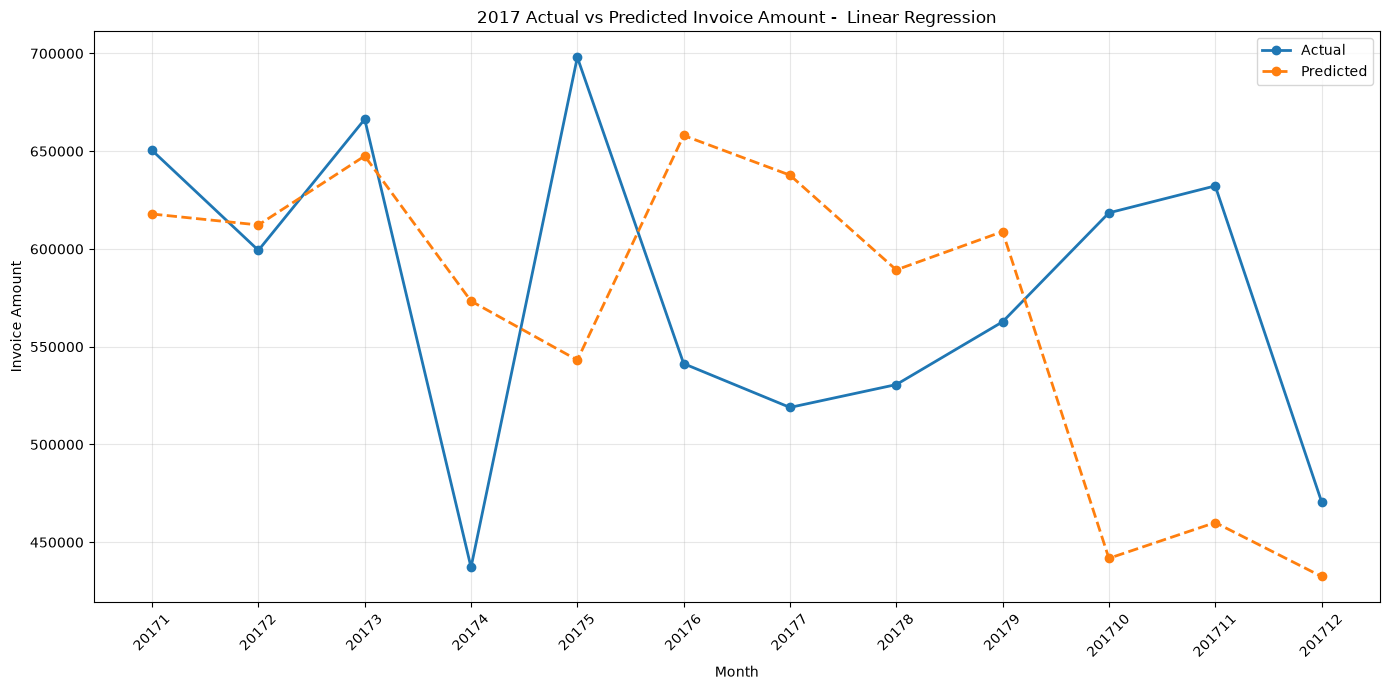

In [113]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

#configure plot
plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount -  Linear Regression")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")
#make x-axis labels more readable
plt.xticks(rotation=45)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS8_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations: Hypothesis 8 - Linear Regression Model - Test Plot

The prediction model is close to the original but slightly skewed to right more than the actual data
Will have a look at Random Forest and see if that is closer

## Look At The DataFrames For Confirmation Of Model Accuracy

Look as dfPLot as this shows actual and predicted value

In [114]:
#show DataFrame for prediction vs actual
dfPlot

,YearMonth,InvoiceAmt,Predicted_InvoiceAmt,Difference,DifferencePercent
0,20171,650412.12,617868.137787,32543.982213,5.003594
1,20172,599293.48,612276.445989,-12982.965989,-2.166379
2,20173,666348.29,647531.676740,18816.613260,2.823841
3,20174,437180.74,573343.513160,-136162.773160,-31.145648
4,20175,698024.62,543184.176045,154840.443955,22.182662
5,20176,541352.49,658029.313655,-116676.823655,-21.552838
6,20177,518946.20,637745.370660,-118799.170660,-22.892387
7,20178,530633.43,589290.983416,-58657.553416,-11.054251
8,20179,562733.90,608870.764890,-46136.864890,-8.198700
9,201710,618465.98,441783.874620,176682.105380,28.567797


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrame it is
clear this is not the case as there are differences in the values, the model works to a degree

Next Random Forest

# Hypothesis 8 - Random Forest - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [115]:
#group data by invoice total per month per territory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)

#create test and training data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

#set train and test data 
dfTrain = dfSalesDataML_Work[dfSalesDataML_Work["Year"] <= 2016].copy()
dfTest = dfSalesDataML_Work[dfSalesDataML_Work["Year"] == 2017].copy()


#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()

# Sort
dfTrain.sort_values(by=["YearMonth", "TerritoryCodes"], inplace=True)
dfTest.sort_values(by=["YearMonth", "TerritoryCodes"],inplace=True)

#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

#configure train
dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "Month",
]

#configure categorial features
lstCategoricalFeatures = [
    "TerritoryCodes"
]

#configure pipeline for Random Forest
objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)

print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

#create DataFrame based on prediction values
dfSalesDataML_2017Predicted = dfTest.copy()
dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")

#create DataFrame for plotting
dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby("YearMonth")[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS8_TEST_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS8_TEST_PATH)



Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Random Forest...
Training complete.

Inspect 2017 Forecast

Actual 2017:    £6,926,442.53
Predicted 2017: £6,513,705.73
Difference:     £412,736.80
Difference %:   5.96%
Random Forest Results
Mean Absolute Error (MAE):  13,980.93
Root Mean Squared Error (RMSE): 23,621.78
R-Squared (R²):   0.7814

                            OLS Regression Results                            
Dep. Variable:             InvoiceAmt   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     213.6
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:28:20   Log-Likelihood:                -19424.
No. Observations:                1669   AIC:                         3.892e+

# Observations: Hypothesis 8 - Random Forest Model - Test

Wow! The R-squared is 0.7814 which is closer to 1 than the Linear Regression Model, even though the predicted
sals total is slightly lower., is the lower total value the best model? Will check using a plot!

The OLS Regression has an R-squared of 0.821 same as the previous!


## Hypothesis 8 - Random Forest Regression Model - Test Plot

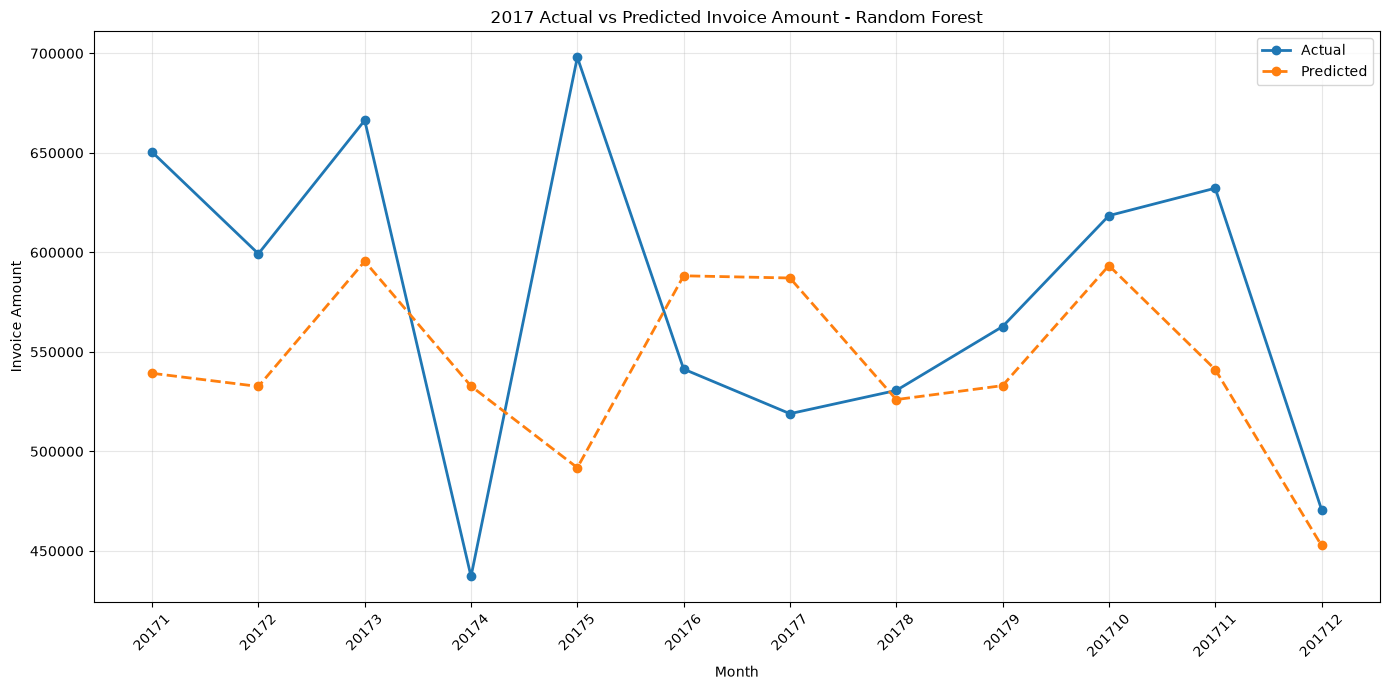

In [116]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

#confgire plot
plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount - Random Forest")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")
plt.xticks(rotation=45)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS8_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)
plt.show()



## Observations: Hypothesis 8 - Random Forest Model - Test Plot

The prediction model is quite close to the original will still include both plots in the dashboard so the customer
can see for themselves the difference

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the dfPlot DataFrame as this shows actual and predicted values

In [117]:
#show DataFrame for prediction vs actual
dfPlot

,YearMonth,InvoiceAmt,Predicted_InvoiceAmt,Difference,DifferencePercent
0,20171,650412.12,539245.952905,111166.167095,17.091651
1,20172,599293.48,532635.255150,66658.224850,11.122802
2,20173,666348.29,595513.680663,70834.609337,10.630268
3,20174,437180.74,532794.020785,-95613.280785,-21.870424
4,20175,698024.62,491817.080096,206207.539904,29.541585
5,20176,541352.49,588233.302547,-46880.812547,-8.659942
6,20177,518946.20,587128.455534,-68182.255534,-13.138598
7,20178,530633.43,526039.356527,4594.073473,0.865772
8,20179,562733.90,533056.745938,29677.154062,5.273746
9,201710,618465.98,593365.389245,25100.590755,4.058524


## Observations: DataFrame Comparison

While the differences betwen projectd values and actual is in some rows greater than the actual, the model plot is
al lot more acceptable then the Linear Regression model, so the Random Forest model is a better fit for this data


## Predict 2018 Figures

Same routine but now predicting unknown values

In [118]:
#this code was originally modified by chatGPT

#get data
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy()

#create special Month column (which incidentally overwrites the existing one!)
dfSalesDataML_Work["Month"] = (dfSalesDataML_Work["YearMonth"] % 100).astype(int)

#cyclic features - no idea what htis does but ML with dates seems to cause problems!
dfSalesDataML_Work["MonthSin"] = np.sin(2 * np.pi * dfSalesDataML_Work["Month"] / 12)
dfSalesDataML_Work["MonthCos"] = np.cos(2 * np.pi * dfSalesDataML_Work["Month"] / 12)

#train using 2011-2017 data
dfTrain = dfSalesDataML_Work[dfSalesDataML_Work["Year"] <= 2017].copy()

print("Training Rows:", len(dfTrain))
print("Training Years:", sorted(dfTrain["Year"].unique()))
print()

#configure features
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

#configure target
strTarget = "InvoiceAmt"

#configure train
dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

#configure categorial features
lstCategoricalFeatures = [
    "TerritoryCodes"
]

#configure pipeline
objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)

#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train
print("Training Linear Regression using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()

# Get all territories that existed in 2017
lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)

# Create 12 months for every territory
df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)

#predict 2018
dfX2018 = df2018Predict[
    lstFeatures
]

obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)

# Add predictions
df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions

#show 2018 forecast
print("2018 Forecast")
print("=" * 30)

#prediction totals
flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)

print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)

#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS8_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS8_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Linear Regression using 2011-2017...
Training complete.

2018 Forecast
    YearMonth  Predicted_InvoiceAmt
0      201801         535188.209847
1      201802         556423.201245
2      201803         578288.933383
3      201804         594926.500995
4      201805         601877.881274
5      201806         597280.457488
6      201807         582366.105628
7      201808         561131.114230
8      201809         539265.382091
9      201810         522627.814480
10     201811         515676.434201
11     201812         520273.857987
          TerritoryCodes  Predicted_InvoiceAmt
0       Central/E.Anglia          1.534338e+05
1                     EU          2.605707e+05
2     EU - OTHER  EUROPE         -6.511756e+04
3                 EU INV         -4.170324e+04
4            East Anglia          1.924939e+05
5          East Midl

## Observations: Predict 2018 Figures - Linear Regression Model

Wow! The R-squared is 0.7814, which is close enough to 1 to say this model works!

The OLS Regression has an R-squared of 0.821 for InvoiceAmt is also near 1, this proves that Hypothesis Zero is
not met with this regression model, next will put in a plot


## Predict 2018 Figures - Linear Regression Plot

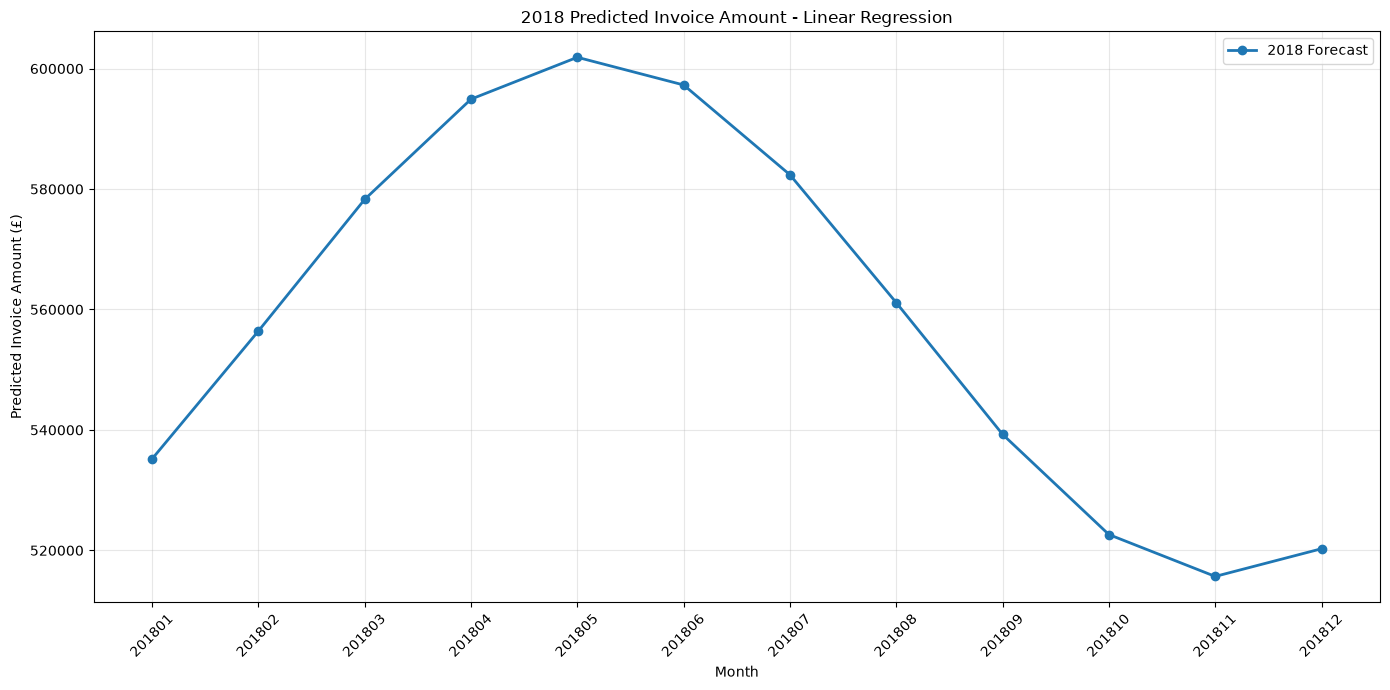

In [119]:
#now plot the results for 2018 prediction 

#configure plot
plt.figure(figsize=(14, 7))

plt.plot(
    df2018Monthly["YearMonth"].astype(str),
    df2018Monthly["Predicted_InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="2018 Forecast"
)

plt.title("2018 Predicted Invoice Amount - Linear Regression")
plt.xlabel("Month")
plt.ylabel("Predicted Invoice Amount (£)")
#make sure labels are readable
plt.xticks(rotation=45)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS8_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Observations: Hypothesis 9 - Linear Regression Model - Prediction Plot

It is a nice curve, but the actual data for previous years significant peaks and troughs, will see what using
Random Forest does before making a decision

## Predict 2018 Figures - Random Forest

In [120]:
#this code was originally modified by chatGPT

#get data
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy()

#create special month column
dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)

#cyclic features (??)
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

#user 2011-2017 as training data
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()

print("Training Rows:", len(dfTrain))
print("Training Years:",    sorted(dfTrain["Year"].unique()))
print()

#configure features
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

#set target
strTarget = "InvoiceAmt"

#configure train
dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

#configure categorial features
lstCategoricalFeatures = [
    "TerritoryCodes"
]

objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

#configure pipeline
objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)

#model
#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


#train
print("Training Random Forest using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()

#predict 2018
# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)

# Create 12 months for every territory
df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)

#create prediction
dfX2018 = df2018Predict[
    lstFeatures
]

obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)

# Add predictions
df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions

print("2018 Forecast")
print("=" * 30)

#get totals
flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)

print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)

#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS8_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS8_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Random Forest using 2011-2017...
Training complete.

2018 Forecast
    YearMonth  Predicted_InvoiceAmt
0      201801         662354.324027
1      201802         528537.101245
2      201803         629801.451314
3      201804         581893.138868
4      201805         603579.900279
5      201806         587500.626374
6      201807         601664.569448
7      201808         603986.288070
8      201809         624505.868337
9      201810         642969.430314
10     201811         644129.585815
11     201812         565985.175797
          TerritoryCodes  Predicted_InvoiceAmt
0       Central/E.Anglia          1.006948e+05
1                     EU          3.766680e+05
2     EU - OTHER  EUROPE          6.866842e+04
3                 EU INV          3.331390e+04
4            East Anglia          5.123335e+04
5          East Midlands

## Observations: Predict 2018 Figures - Random Forest Model

Better than the Linear Regression model (?), so will see what the plots look like before making a decision

## Predict 2018 Figures- Random Forest Plot

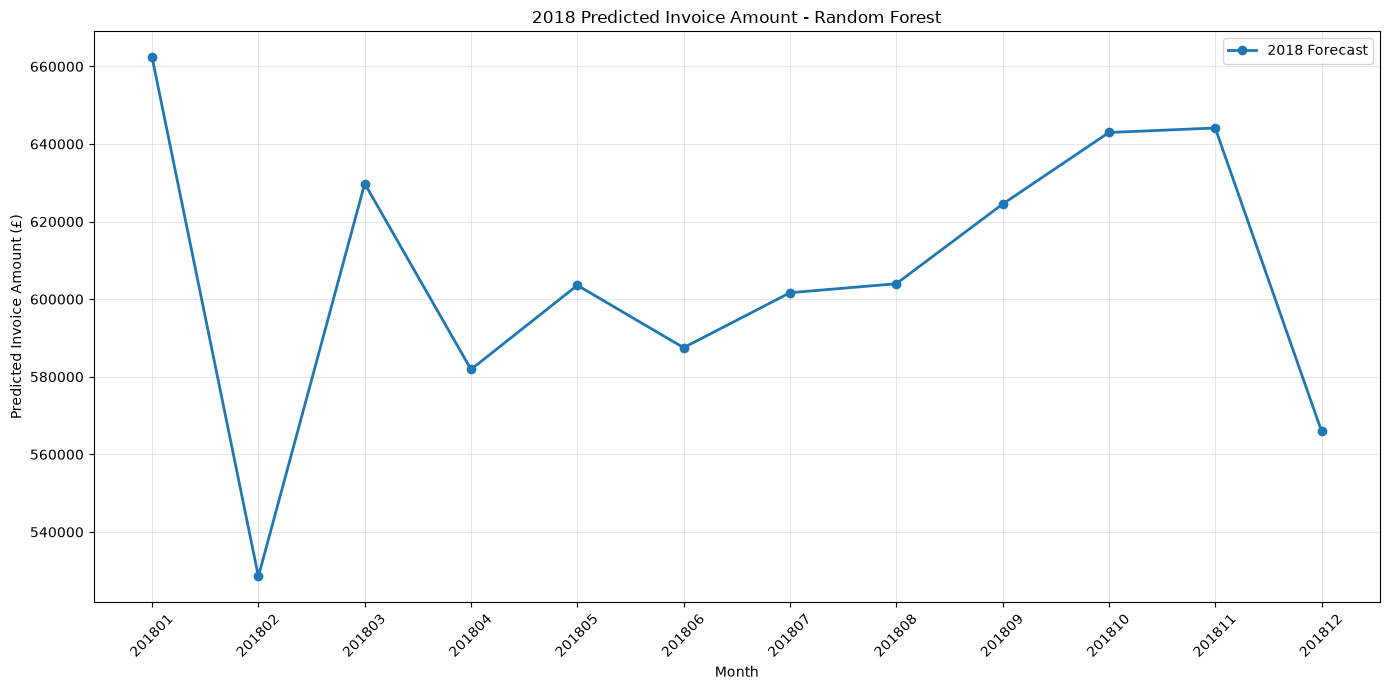

In [121]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

#configure plot
plt.figure(figsize=(14, 7))

plt.plot(
    df2018Monthly["YearMonth"].astype(str),
    df2018Monthly["Predicted_InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="2018 Forecast"
)

plt.title("2018 Predicted Invoice Amount - Random Forest")
plt.xlabel("Month")
plt.ylabel("Predicted Invoice Amount (£)")
#make sure axis labels are readable
plt.xticks(rotation=45)
#show legend
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS8_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations: Hypothesis 8 - Random Forest Prediciton Plot

Looks a lot closer to historical data, unlike the Linear Regression model, but will still use both on the dashboard to
show the difference in accuracy

# Hypothesis 9

What are the predicted sales per territory for next year?

# Hypothesis 9 - Linear Regression Model - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [122]:
#group data by invoice total per month per territory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory Per Month: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and traing data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))
print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "Month",
]

#configure categorial features
lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train
print("Training Linear Regression...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()

#for statistical comparison 
dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby(["YearMonth","TerritoryCodes"])[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save pipelie to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH
)

#tell user saved
print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH)


Invoice Amounts Per Territory Per Month: 2011 To 2016
Training Rows: 1669
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
Training Linear Regression...
Training complete.

Inspect 2017 Forecast

Actual 2017:    £6,926,442.53
Predicted 2017: £6,822,533.17
Difference:     £103,909.36
Difference %:   1.50%

 YearMonth       TerritoryCodes  InvoiceAmt  Predicted_InvoiceAmt     Difference  DifferencePercent
     20171     Central/E.Anglia    13166.22          17083.713248   -3917.493248      -2.975412e+01
     20171                   EU    46796.81          23334.184677   23462.625323       5.013723e+01
     20171               EU INV     4018.60           -890.092903    4908.692903       1.221493e+02
     20171        East Midlands    22622.3

# Observations: Hypothesis 9 - Linear Regression Model - Test

Wow! The R-squared is 0.4587 which is is close to midway but not conclusive the model works

The OLS Regression has an R-squared of 0.412 while InvoiceAmt is also nearer to 0, this does not prove that 
Hypothesis Zero is not met with this regression model, next it will put in a plot

# Hypothesis 9 - Linear Regression Plot - Test Plot  

Visualise the model results

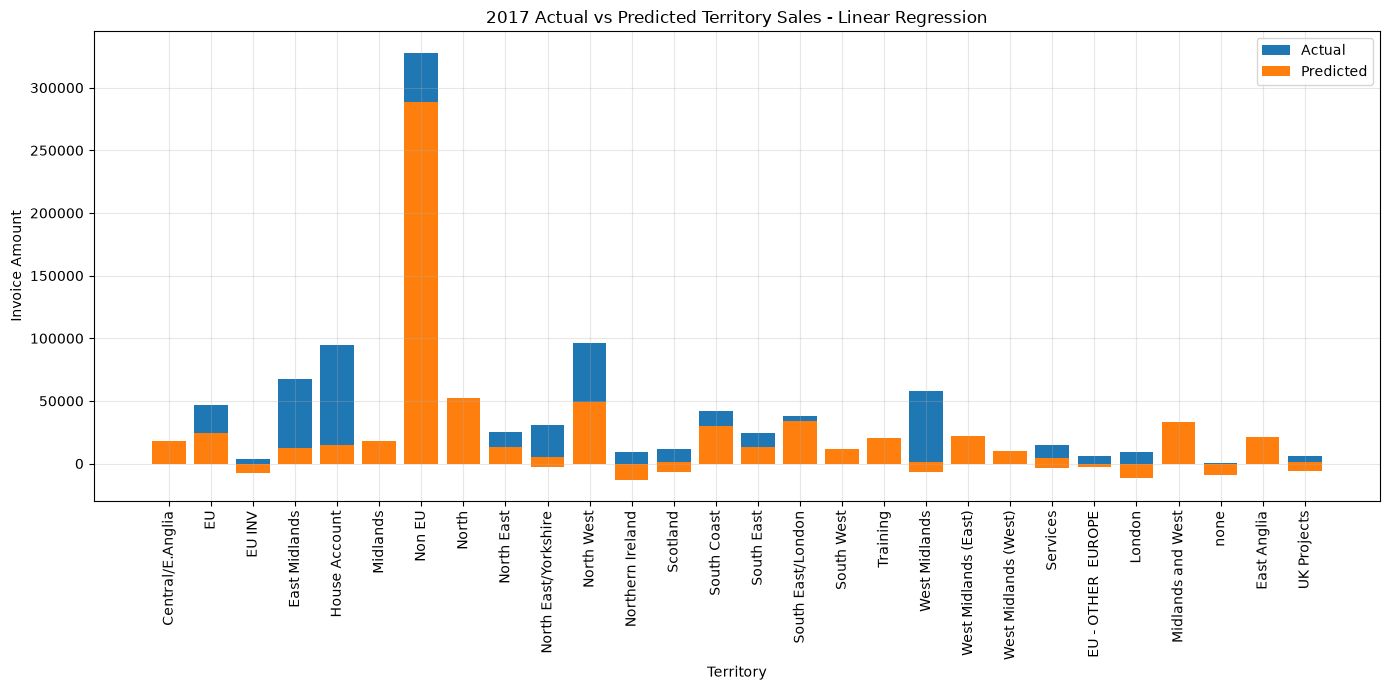

In [ ]:
#now plot the results for 2017 prediction with actual 2017 territory sales and previous year 2016 sales

#configure plot
plt.figure(figsize=(14, 7))

plt.bar(
    dfPlot["TerritoryCodes"], 
    dfPlot["InvoiceAmt"],
    label="Actual"
)

plt.bar(
    dfPlot["TerritoryCodes"],      
    dfPlot["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Territory Sales - Linear Regression")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")
#make sure axis labels are readable
plt.xticks(rotation=90)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS9_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations: Hypothesis 9 - Linear Regression Model - Test Plot

The prediction model is close to the original but slightly skewed to right more than the actual data
Will have a look at Random Forest and see if that is closer

## Look At The DataFrame For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [124]:
#show DataFrame for prediction vs actual
dfPlot

,YearMonth,TerritoryCodes,InvoiceAmt,Predicted_InvoiceAmt,Difference,DifferencePercent
0,20171,Central/E.Anglia,13166.22,17083.713248,-3917.493248,-29.754123
1,20171,EU,46796.81,23334.184677,23462.625323,50.137232
2,20171,EU INV,4018.60,-890.092903,4908.692903,122.149328
3,20171,East Midlands,22622.31,11675.208602,10947.101398,48.390732
4,20171,House Account,66390.59,13659.962963,52730.627037,79.424851
...,...,...,...,...,...,...
246,201712,South East/London,12316.12,26855.816908,-14539.696908,-118.054200
247,201712,South West,8935.62,4173.576194,4762.043806,53.292819
248,201712,UK Projects,6374.36,-6036.739844,12411.099844,194.703466
249,201712,West Midlands,23972.99,-6553.462685,30526.452685,127.336860


In [125]:
#compare with actual 2017 data
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()
dfSalesDataML_Temp

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Noticable variances between the predicted and actual values, will see what the model looks like


# Random Forest - Hypothesis 9 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [126]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and training data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

#configure train
dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "Month",
]

#configure categorial features
lstCategoricalFeatures = [
    "TerritoryCodes"
]

objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)



#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)
print()


print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


#for statistical comparison 
dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby(["YearMonth","TerritoryCodes"])[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)

#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH)



Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
Training Random Forest...

Training complete.

Inspect 2017 Forecast

Actual 2017:    £6,926,442.53
Predicted 2017: £6,513,705.73
Difference:     £412,736.80
Difference %:   5.96%

 YearMonth       TerritoryCodes  InvoiceAmt  Predicted_InvoiceAmt    Difference  DifferencePercent
     20171     Central/E.Anglia    13166.22           6824.795489   6341.424511       4.816435e+01
     20171                   EU    46796.81          37978.185425   8818.624575       1.884450e+01
     20171               EU INV     4018.60           4000.447633     18.152367       4.517087e-01
     20171        East Midlands    22622.31           3241.

# Observations: Hypothesis 9 - Random Forest Model - Test

Wow! The R-squared is 0.7459 which is a really good figure, hypothesis Zero is not met!

The OLS Regression has an R-squared of 0.000 which tells us this model doesn't work, but this is based on **just**
InvoiceAmt and so shall wait till the plot before making a final decision


## Hypothesis 9 - Random Forest Model - Test Plot


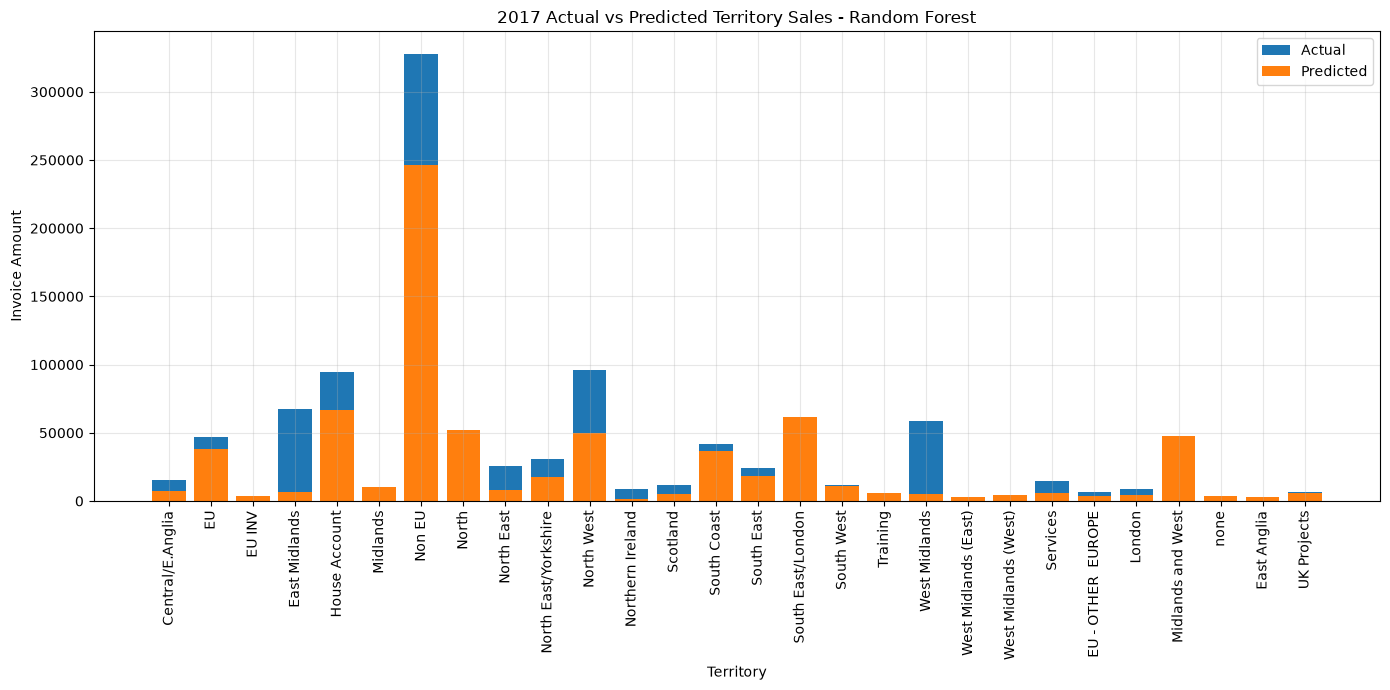

In [127]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

#configure plot
plt.figure(figsize=(14, 7))

plt.bar(
    dfPlot["TerritoryCodes"], 
    dfPlot["InvoiceAmt"],
    label="Actual"
)

plt.bar(
    dfPlot["TerritoryCodes"],      
    dfPlot["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Territory Sales - Random Forest")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")
#make sure axis labels are readable
plt.xticks(rotation=90)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS9_TEST_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observations: Hypothesis 9 - Random Forest Model - Test Plot

The prediction model is quite close to the original will still include both plots in the dashboard so the customer
can see for themselves the difference

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [128]:
#2017 prediction model DataFrame
dfPlot

,YearMonth,TerritoryCodes,InvoiceAmt,Predicted_InvoiceAmt,Difference,DifferencePercent
0,20171,Central/E.Anglia,13166.22,6824.795489,6341.424511,48.164352
1,20171,EU,46796.81,37978.185425,8818.624575,18.844499
2,20171,EU INV,4018.60,4000.447633,18.152367,0.451709
3,20171,East Midlands,22622.31,3241.986128,19380.323872,85.669076
4,20171,House Account,66390.59,54570.069884,11820.520116,17.804511
...,...,...,...,...,...,...
246,201712,South East/London,12316.12,18167.165500,-5851.045500,-47.507214
247,201712,South West,8935.62,8230.642207,704.977793,7.889523
248,201712,UK Projects,6374.36,5623.698744,750.661256,11.776261
249,201712,West Midlands,23972.99,4809.880070,19163.109930,79.936253


In [129]:
#compare with actual 2017 data
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()
dfSalesDataML_Temp.sort_values(by=["TerritoryCodes"], inplace=True)
dfSalesDataML_Temp


,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1083,1419,Central/E.Anglia,20172,2017,11226.51
1115,1420,Central/E.Anglia,20173,2017,5984.90
1122,1421,Central/E.Anglia,20174,2017,15467.32
1141,1422,Central/E.Anglia,20175,2017,6496.81
...,...,...,...,...,...
1668,1664,West Midlands (East),201712,2017,142.36
1056,1665,West Midlands (West),20171,2017,346.90
1086,1666,West Midlands (West),20172,2017,258.65
1640,1667,West Midlands (West),201711,2017,148.90


## Observations: DataFrame Comparison

Data does not look too bad, the predicted values are not far off

## Predict 2018 Figures - Linear Regression Model

In [130]:
#code originally modified by chatGPT

#get data
dfSalesDataML_Work = (dfSalesDataML_GroupedByTerritory.copy())
#create special month column
dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)

#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)
#train using 2011-2017 data
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()

print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)
print()


#configure features
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

#set target
strTarget = "InvoiceAmt"

#configue train
dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

#set numeric features
lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

#set categorical features
lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)

#model
objModel = LinearRegression()

#configure pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train
print("Training Linear Regression using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()

#predict 2018
# Get all territories that existed in 2017
lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)

# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)

#predict 2018
dfX2018 = df2018Predict[
    lstFeatures
]

obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions
df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions

print("2018 Forecast")
print("=" * 30)

#totals
flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)

print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)

#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Linear Regression using 2011-2017...
Training complete.

2018 Forecast
    YearMonth  Predicted_InvoiceAmt
0      201801         535188.209836
1      201802         556423.201225
2      201803         578288.933356
3      201804         594926.500964
4      201805         601877.881243
5      201806         597280.457461
6      201807         582366.105609
7      201808         561131.114220
8      201809         539265.382089
9      201810         522627.814482
10     201811         515676.434203
11     201812         520273.857984
          TerritoryCodes  Predicted_InvoiceAmt
0       Central/E.Anglia          1.534338e+05
1                     EU          2.605707e+05
2     EU - OTHER  EUROPE         -6.511756e+04
3                 EU INV         -4.170324e+04
4            East Anglia          1.924939e+05
5          East Midl

## Predict 2018 Figures - Linear Regression - Plot

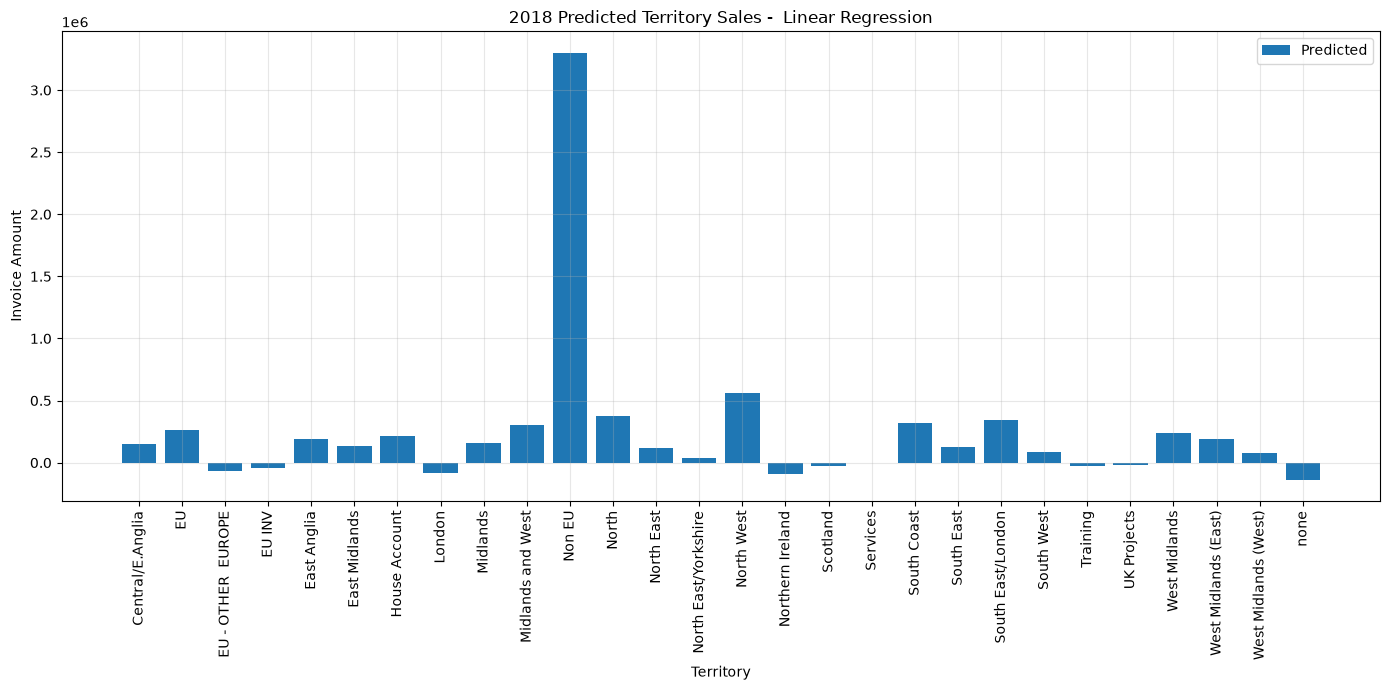

In [131]:
#now plot the results for 2018 prediction 

#configure plot
plt.figure(figsize=(14, 7))

plt.bar(
    df2018Territory["TerritoryCodes"],      
    df2018Territory["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2018 Predicted Territory Sales -  Linear Regression")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")
#make sure axis labels are readable
plt.xticks(rotation=90)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

#save plot to file in reports folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS9_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Predict 2018 Figures - Random Forest Model

In [132]:
#code originally modified by chatGPT

#get data
dfSalesDataML_Work = (dfSalesDataML_GroupedByTerritory.copy())

#create special month column
dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)

#cyclic features (??)
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

#train using data from 2011-2017
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()

print("Training Rows:", len(dfTrain))
print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)
print()

#configure features 
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

#set target
strTarget = "InvoiceAmt"

#configure train
dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

#configure numeric features
lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

#configure categorical features
lstCategoricalFeatures = [
    "TerritoryCodes"
]

objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)

#model
#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#configure pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


#train maodel
print("Training Random Forest using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)
print("Training complete.")
print()

#predict 2018
# Get all territories that existed in 2017
lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)

# Create 12 months for every territory
df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)

#predict 2018 
dfX2018 = df2018Predict[
    lstFeatures
]

obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)

# Add predictions
df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions

print("2018 Forecast")
print("=" * 30)

#totals
flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)

print(
    f"Predicted 2018 Territory Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Random Forest using 2011-2017...
Training complete.

2018 Forecast
    YearMonth  Predicted_InvoiceAmt
0      201801         662354.324027
1      201802         528537.101245
2      201803         629801.451314
3      201804         581893.138868
4      201805         603579.900279
5      201806         587500.626374
6      201807         601664.569448
7      201808         603986.288070
8      201809         624505.868337
9      201810         642969.430314
10     201811         644129.585815
11     201812         565985.175797
          TerritoryCodes  Predicted_InvoiceAmt
0       Central/E.Anglia          1.006948e+05
1                     EU          3.766680e+05
2     EU - OTHER  EUROPE          6.866842e+04
3                 EU INV          3.331390e+04
4            East Anglia          5.123335e+04
5          East Midlands

## Predict 2018 Figures - Random Forest Model - Plot

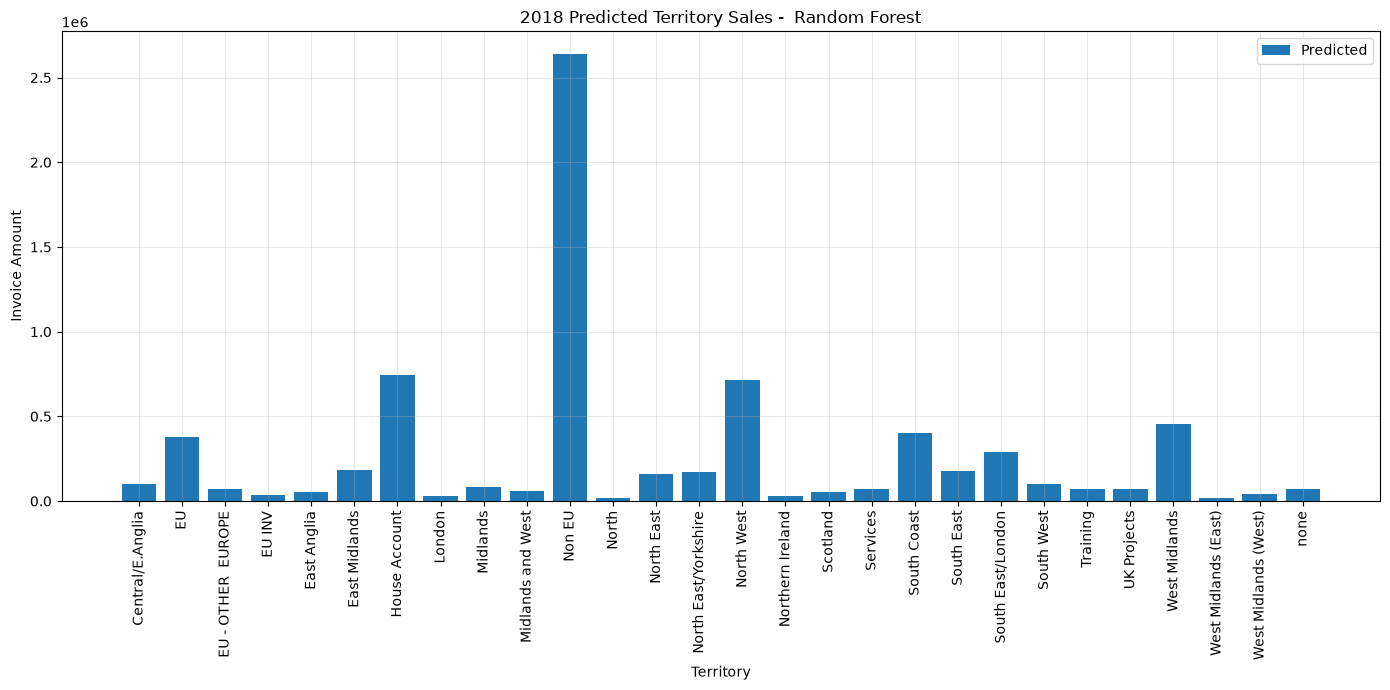

In [133]:
#now plot the results for 2018 prediction 

#configure plot
plt.figure(figsize=(14, 7))

plt.bar(
    df2018Territory["TerritoryCodes"],      
    df2018Territory["Predicted_InvoiceAmt"],
    label="Predicted"
)

plt.title("2018 Predicted Territory Sales -  Random Forest")
plt.xlabel("Territory")
plt.ylabel("Invoice Amount")
#make sure axis labels are readable
plt.xticks(rotation=90)
#show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#save plot to file in reports folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS9_PREDICTIONS_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Predict 2018 Figures - Random Forest Model - Plot

Strangely the Linear Regression Model is show the **exact** values for MAE, RMSE, and R-squared as the Random Forest Model, no idea how this can happen!

## Conclusions

The models were a good test, the Random Forest model is a better fit for this data, but the Linear Regression model is also a lesser fit and will be included in the dashboard to show the differences between the two models